In [74]:
!pip install pandas numpy requests

In [75]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta

In [76]:
import os
DATA_PATH = os.path.join("..", "data", "processed", "traffic_enriched.csv")

In [77]:
def traffic_pattern(hour):
    if 7 <= hour <= 9 or 18 <= hour <= 20:
        velocidad = float(np.clip(np.random.normal(18, 5), 5, 30))
        densidad = float(np.clip(np.random.normal(2.6, 0.25), 1, 3))
        detenciones = int(np.random.randint(1, 4))

    elif 10 <= hour <= 17:
        velocidad = float(np.clip(np.random.normal(35, 6), 15, 55))
        densidad = float(np.clip(np.random.normal(1.8, 0.30), 1, 3))
        detenciones = int(np.random.randint(0, 3))

    else:
        velocidad = float(np.clip(np.random.normal(55, 7), 30, 75))
        densidad = float(np.clip(np.random.normal(1.2, 0.20), 1, 3))
        detenciones = int(np.random.randint(0, 2))

    return round(velocidad, 2), round(densidad, 2), detenciones

In [78]:
def generate_time_series(start_time, periods=288, intervals=5):
    data = []
    current_time = start_time

    for _ in range(periods):
        hour = current_time.hour
        v, d, det = traffic_pattern(hour)
        data.append({
            "timestamp": current_time,
            "avenida": "Simulada_ZMG",
            "velocidad": v,
            "densidad": d,
            "detenciones": det
        })
        current_time += timedelta(minutes=intervals)

    return pd.DataFrame(data)

df_sim = generate_time_series(datetime(2026, 3, 20, 0, 0))
df_sim.head()

,timestamp,avenida,velocidad,densidad,detenciones
0,2026-03-20 00:00:00,Simulada_ZMG,56.71,1.32,0
1,2026-03-20 00:05:00,Simulada_ZMG,56.18,1.07,0
2,2026-03-20 00:10:00,Simulada_ZMG,68.40,1.02,1
3,2026-03-20 00:15:00,Simulada_ZMG,53.99,1.21,0
4,2026-03-20 00:20:00,Simulada_ZMG,65.95,1.25,1


In [79]:
url = url = "https://api.open-meteo.com/v1/forecast?latitude=20.67&longitude=-103.35&current_weather=true"

response = requests.get(url)
weather_data = response.json()
weather_data


{'latitude': 20.625,
 'longitude': -103.375,
 'generationtime_ms': 0.09489059448242188,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 1546.0,
 'current_weather_units': {'time': 'iso8601',
  'interval': 'seconds',
  'temperature': '°C',
  'windspeed': 'km/h',
  'winddirection': '°',
  'is_day': '',
  'weathercode': 'wmo code'},
 'current_weather': {'time': '2026-03-20T18:00',
  'interval': 900,
  'temperature': 25.1,
  'windspeed': 12.2,
  'winddirection': 88,
  'is_day': 1,
  'weathercode': 0}}

In [80]:
weather = weather_data["current_weather"]

df_weather = pd.DataFrame([{
    "temperatura": weather["temperature"],
    "viento": weather["windspeed"]
}])

df_weather


,temperatura,viento
0,25.1,12.2


In [81]:
df_sim["temperatura"] = df_weather["temperatura"].iloc[0]
df_sim["viento"] = df_weather["viento"].iloc[0]
df_sim.head()

,timestamp,avenida,velocidad,densidad,detenciones,temperatura,viento
0,2026-03-20 00:00:00,Simulada_ZMG,56.71,1.32,0,25.1,12.2
1,2026-03-20 00:05:00,Simulada_ZMG,56.18,1.07,0,25.1,12.2
2,2026-03-20 00:10:00,Simulada_ZMG,68.40,1.02,1,25.1,12.2
3,2026-03-20 00:15:00,Simulada_ZMG,53.99,1.21,0,25.1,12.2
4,2026-03-20 00:20:00,Simulada_ZMG,65.95,1.25,1,25.1,12.2


In [82]:
df_sim["hora"] = df_sim["timestamp"].dt.hour
df_sim["dia_semana"] = df_sim["timestamp"].dt.dayofweek
df_sim.head()

,timestamp,avenida,velocidad,densidad,detenciones,temperatura,viento,hora,dia_semana
0,2026-03-20 00:00:00,Simulada_ZMG,56.71,1.32,0,25.1,12.2,0,4
1,2026-03-20 00:05:00,Simulada_ZMG,56.18,1.07,0,25.1,12.2,0,4
2,2026-03-20 00:10:00,Simulada_ZMG,68.40,1.02,1,25.1,12.2,0,4
3,2026-03-20 00:15:00,Simulada_ZMG,53.99,1.21,0,25.1,12.2,0,4
4,2026-03-20 00:20:00,Simulada_ZMG,65.95,1.25,1,25.1,12.2,0,4


In [83]:
def normalize_with_bounds(series, min_value, max_value):
    clipped = series.clip(lower=min_value, upper=max_value)
    return (clipped - min_value) / (max_value - min_value)

df_sim["velocidad_norm"] = normalize_with_bounds(df_sim["velocidad"], 5, 75)
df_sim["densidad_norm"] = normalize_with_bounds(df_sim["densidad"], 1, 3)
df_sim["detenciones_norm"] = normalize_with_bounds(df_sim["detenciones"], 0, 4)

df_sim["speed_congestion"] = 1 - df_sim["velocidad_norm"]

In [84]:
df_sim["TSI"] = (
    0.5 * df_sim["densidad_norm"]
    + 0.3 * df_sim["detenciones_norm"]
    + 0.2 * df_sim["speed_congestion"]
).round(4)

df_sim[["timestamp", "velocidad", "densidad", "detenciones", "TSI"]].head()

,timestamp,velocidad,densidad,detenciones,TSI
0,2026-03-20 00:00:00,56.71,1.32,0,0.1323
1,2026-03-20 00:05:00,56.18,1.07,0,0.0713
2,2026-03-20 00:10:00,68.40,1.02,1,0.0989
3,2026-03-20 00:15:00,53.99,1.21,0,0.1125
4,2026-03-20 00:20:00,65.95,1.25,1,0.1634


In [85]:
df_sim[["velocidad_norm","densidad_norm","detenciones_norm","TSI"]]

,velocidad_norm,densidad_norm,detenciones_norm,TSI
0,0.738714,0.160,0.00,0.1323
1,0.731143,0.035,0.00,0.0713
2,0.905714,0.010,0.25,0.0989
3,0.699857,0.105,0.00,0.1125
4,0.870714,0.125,0.25,0.1634
...,...,...,...,...
283,0.565857,0.045,0.00,0.1093
284,0.736143,0.150,0.25,0.2028
285,0.700429,0.130,0.25,0.1999
286,0.798286,0.000,0.00,0.0403


<Axes: >

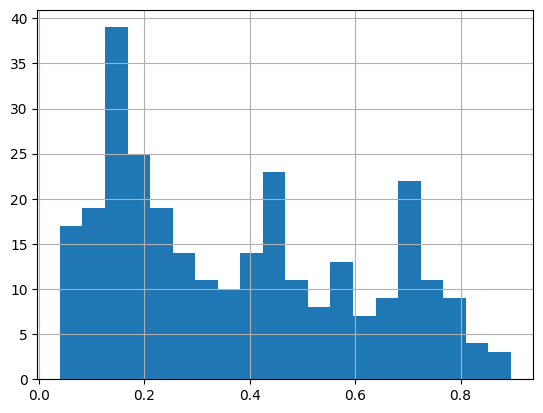

In [86]:
df_sim["TSI"].hist(bins=20)

In [87]:
import os
os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
df_sim.to_csv(DATA_PATH, index=False)

In [88]:
import os
print("Ruta configurada:", DATA_PATH)
print("Ruta absoluta:", os.path.abspath(DATA_PATH))
print("¿Archivo existe?:", os.path.exists(DATA_PATH))

Ruta configurada: ..\data\processed\traffic_enriched.csv
Ruta absoluta: c:\Users\REYES\OneDrive\Desktop\TSI\data\processed\traffic_enriched.csv
¿Archivo existe?: True


In [89]:
# Diagnóstico compacto de variación del TSI
print("% ceros en TSI:", round((df_sim["TSI"] == 0).mean() * 100, 2), "%")
print("TSI min/max:", round(df_sim["TSI"].min(), 4), round(df_sim["TSI"].max(), 4))
print("TSI std:", round(df_sim["TSI"].std(), 4))

% ceros en TSI: 0.0 %
TSI min/max: 0.0403 0.8953
TSI std: 0.2329


In [90]:
# Clasificación del TSI en niveles interpretables
df_sim["nivel_tsi"] = pd.cut(
    df_sim["TSI"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Fluido", "Moderado", "Congestionado"]
)

# Resumen por hora: promedio de TSI y distribución de niveles
resumen_hora = (
    df_sim.groupby("hora", as_index=False)
    .agg(
        tsi_promedio=("TSI", "mean"),
        conteo=("TSI", "size")
    )
)
resumen_hora["tsi_promedio"] = resumen_hora["tsi_promedio"].round(3)

niveles_hora = pd.crosstab(df_sim["hora"], df_sim["nivel_tsi"])

print("Resumen por hora (TSI promedio):")
display(resumen_hora)

print("Distribución de niveles por hora:")
display(niveles_hora)

print("Distribución global de niveles:")
display(df_sim["nivel_tsi"].value_counts(normalize=True).mul(100).round(2).rename("porcentaje"))

Resumen por hora (TSI promedio):


,hora,tsi_promedio,conteo
0,0,0.150,12
1,1,0.169,12
2,2,0.159,12
3,3,0.150,12
4,4,0.155,12
5,5,0.163,12
6,6,0.154,12
7,7,0.678,12
8,8,0.703,12
9,9,0.739,12


Distribución de niveles por hora:


nivel_tsi,Fluido,Moderado,Congestionado
hora,,,
0,12,0,0
1,11,1,0
2,12,0,0
3,12,0,0
4,12,0,0
5,11,1,0
6,12,0,0
7,0,2,10
8,0,1,11


Distribución global de niveles:


nivel_tsi
Fluido           46.18
Moderado         31.25
Congestionado    22.57
Name: porcentaje, dtype: float64